<a href="https://colab.research.google.com/github/vishwakarmaadesh-datascience/multi-disease-prediction-system-ensemble-learning/blob/main/Bitcoin_Market_Sentiment(Fear_Greed).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
fear_greed_index = pd.read_csv('/content/fear_greed_index.csv')
historical_data = pd.read_csv('/content/historical_data.csv')
print("1st few rows of fear dataset\n",fear_greed_index.head())
print("last few rows of fear dataset\n",fear_greed_index.tail())
print("1st few rows of historical data\n",historical_data.head())
print("last few rows of historical data\n",historical_data.tail())

1st few rows of fear dataset
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
last few rows of fear dataset
        timestamp  value classification        date
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02
1st few rows of historical data
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd5

/tmp/ipykernel_1616/2400278216.py:7: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  historical_data = pd.read_csv('/content/historical_data.csv')


2. EDA Process


In [2]:
# Check shape
print("Fear Greed Shape:", fear_greed_index.shape)
print("Historical Data Shape:", historical_data.shape)
# Preview
fear_greed_index.head()
historical_data.head()
# Info
fear_greed_index.info()
historical_data.info()
# Missing values
print("Fear Greed Missing:\n", fear_greed_index.isnull().sum())
print("Historical Missing:\n", historical_data.isnull().sum())
# Duplicates
print("Fear Greed Duplicates:", fear_greed_index.duplicated().sum())
print("Historical Duplicates:", historical_data.duplicated().sum())
fear_greed_index = fear_greed_index.drop_duplicates()
historical_data = historical_data.drop_duplicates()

Fear Greed Shape: (2644, 4)
Historical Data Shape: (177273, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177273 entries, 0 to 177272
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           177273 non-null  object 
 1   Coin              177272 non-null  object 
 2   Execution Price   177272 non-null  float64
 3   Size Tokens       177272 non-null  float64
 4   Size USD          177272 non-null  float64
 5   Side              177272 non-null  object 
 6   Timestamp IST  

In [3]:
#Convert timestamps and aligning the dataset by date
# Fear & Greed dataset
fear_greed_index['date'] = pd.to_datetime(fear_greed_index['date'])
# Historical dataset (check column name'time')
historical_data['Timestamp IST'] = pd.to_datetime(historical_data['Timestamp IST'], dayfirst=True)
historical_data['Date'] = historical_data['Timestamp IST'].dt.date
fear_greed_index['Date'] = fear_greed_index['date'].dt.date
print('Fear and Greed Index after date conversion:')
display(fear_greed_index.head())
print('\nHistorical Data after date conversion:')
display(historical_data.head())

# Merge DataFrames on the 'Date' column
merged_data = pd.merge(historical_data, fear_greed_index, on='Date', how='inner')
print("Merged Data after joining:")
display(merged_data.head())
print(f"\nShape of merged data: {merged_data.shape}")

Fear and Greed Index after date conversion:


,timestamp,value,classification,date,Date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05



Historical Data after date conversion:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


Merged Data after joining:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02



Shape of merged data: (177266, 21)


3.Key metrics

In [4]:
# Daily PnL per Trader (or per Account)
daily_pnl_per_account = merged_data.groupby(['Date', 'Account'])['Closed PnL'].sum().reset_index()
print("Daily PnL per Account (first 5 rows):")
display(daily_pnl_per_account.head())

Daily PnL per Account (first 5 rows):


,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [5]:
# Calculate Win Rate
winning_trades = merged_data[merged_data['Closed PnL'] > 0]
total_trades = len(merged_data)
win_rate = (len(winning_trades) / total_trades) * 100 if total_trades > 0 else 0
print(f"Overall Win Rate: {win_rate:.2f}%")

Overall Win Rate: 41.94%


In [6]:
# Calculate Average Trade Size
avg_trade_size_tokens = merged_data['Size Tokens'].mean()
avg_trade_size_usd = merged_data['Size USD'].mean()
print(f"Average Trade Size (Tokens): {avg_trade_size_tokens:.2f}")
print(f"Average Trade Size (USD): {avg_trade_size_usd:.2f}")

Average Trade Size (Tokens): 5314.44
Average Trade Size (USD): 5900.01


In [7]:
# Calculate Number of Trades per Day
trades_per_day = merged_data.groupby('Date').size().reset_index(name='Number of Trades')
print("Number of Trades per Day (first 5 rows):")
display(trades_per_day.head())

Number of Trades per Day (first 5 rows):


,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [8]:
# Calculate Long/Short Ratio
long_trades = merged_data[merged_data['Side'] == 'BUY']
short_trades = merged_data[merged_data['Side'] == 'SELL']

num_long = len(long_trades)
num_short = len(short_trades)

long_short_ratio = num_long / num_short if num_short > 0 else float('inf')
print(f"Number of Long Trades: {num_long}")
print(f"Number of Short Trades: {num_short}")
print(f"Long/Short Ratio: {long_short_ratio:.2f}")

Number of Long Trades: 86357
Number of Short Trades: 90909
Long/Short Ratio: 0.95


4. Analysis of Performance and Behavior based on Sentiment

Performance by Sentiment Classification:


,classification,Closed PnL,Win Rate (%)
0,Extreme Fear,465068.10,35.85
1,Extreme Greed,2623308.66,47.73
2,Fear,2808697.71,43.37
3,Greed,1594082.19,38.36
4,Neutral,1287235.82,41.09


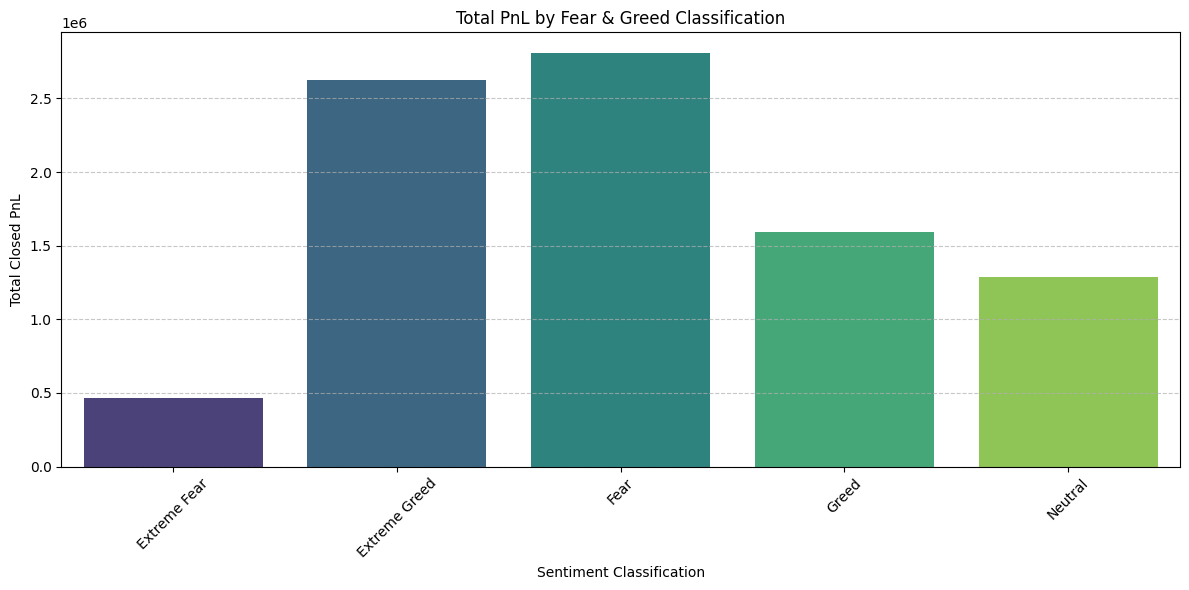

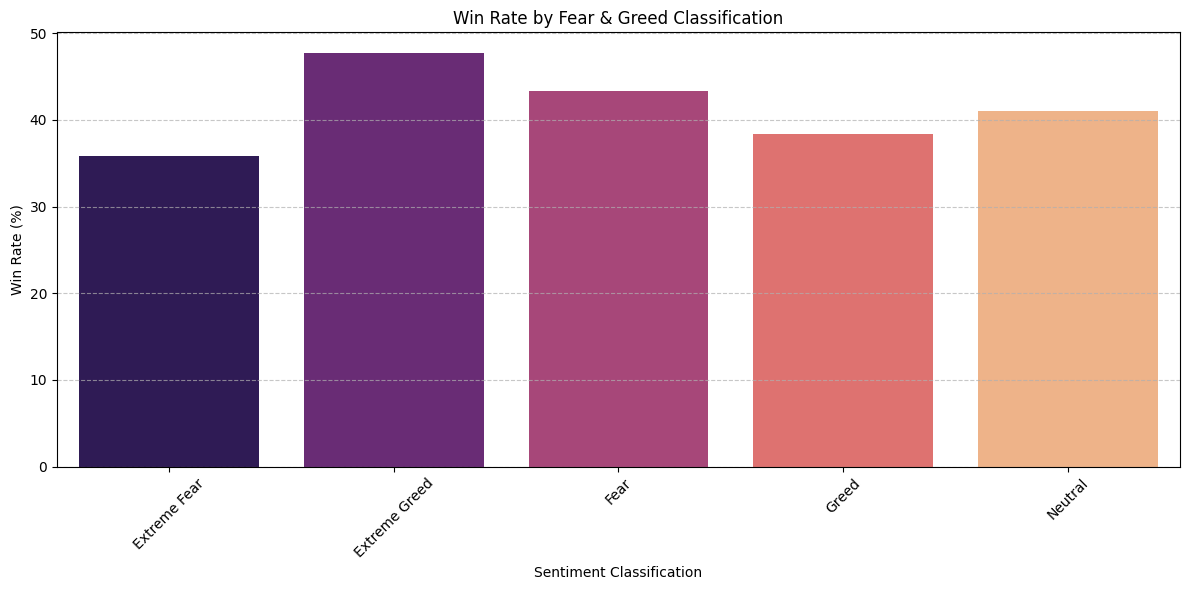

In [9]:
# Trader Behavior differences based on Sentiment
# Calculate total PnL per classification
pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].sum().reset_index()

# Calculate win rate per classification
winning_trades_by_sentiment = merged_data[merged_data['Closed PnL'] > 0].groupby('classification').size().reset_index(name='Winning Trades')
total_trades_by_sentiment = merged_data.groupby('classification').size().reset_index(name='Total Trades')

win_rate_by_sentiment = pd.merge(winning_trades_by_sentiment, total_trades_by_sentiment, on='classification', how='outer').fillna(0)
win_rate_by_sentiment['Win Rate (%)'] = (win_rate_by_sentiment['Winning Trades'] / win_rate_by_sentiment['Total Trades']) * 100

# Merge PnL and Win Rate for a combined view
performance_by_sentiment = pd.merge(pnl_by_sentiment, win_rate_by_sentiment[['classification', 'Win Rate (%)']], on='classification', how='left')

print("Performance by Sentiment Classification:")
display(performance_by_sentiment.round(2))
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting PnL by Sentiment
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='Closed PnL', data=performance_by_sentiment, palette='viridis', hue='classification', legend=False)
plt.title('Total PnL by Fear & Greed Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Plotting Win Rate by Sentiment
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='Win Rate (%)', data=performance_by_sentiment, palette='magma', hue='classification', legend=False)
plt.title('Win Rate by Fear & Greed Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Trade Frequency by Sentiment Classification:


,classification,Trade Count
0,Extreme Fear,16513
1,Extreme Greed,37863
2,Fear,47838
3,Greed,44913
4,Neutral,30139


/tmp/ipykernel_1616/2700601206.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Trade Count', data=trade_frequency_by_sentiment, palette='coolwarm')


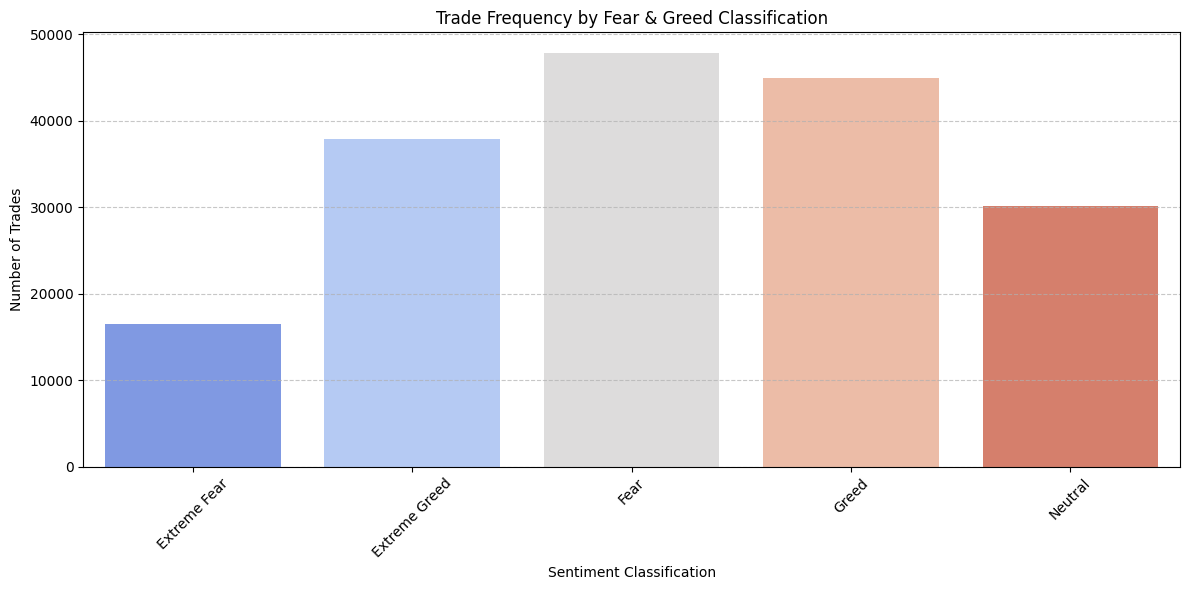

In [10]:
# Trader Behavior differences based on Sentiment
# Calculate trade frequency per sentiment
trade_frequency_by_sentiment = merged_data.groupby('classification').size().reset_index(name='Trade Count')
print("Trade Frequency by Sentiment Classification:")
display(trade_frequency_by_sentiment.round(2))
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='Trade Count', data=trade_frequency_by_sentiment, palette='coolwarm')
plt.title('Trade Frequency by Fear & Greed Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Long/Short Bias by Sentiment Classification:


Side,classification,BUY,SELL,Long/Short Ratio
0,Extreme Fear,8889,7624,1.17
1,Extreme Greed,16653,21210,0.79
2,Fear,23328,24510,0.95
3,Greed,21954,22959,0.96
4,Neutral,15533,14606,1.06


/tmp/ipykernel_1616/4169350343.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Long/Short Ratio', data=long_short_by_sentiment, palette='coolwarm')


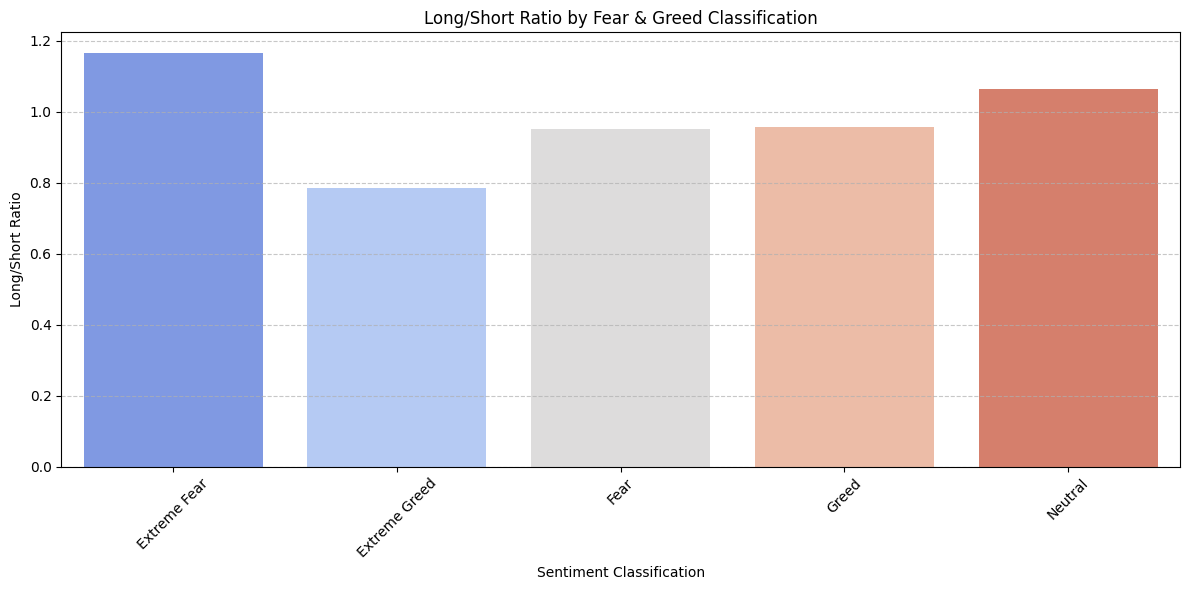

In [11]:
# Calculate Long/Short Ratio per sentiment
long_short_by_sentiment = merged_data.groupby(['classification', 'Side']).size().unstack(fill_value=0).reset_index()
long_short_by_sentiment['Long/Short Ratio'] = long_short_by_sentiment['BUY'] / long_short_by_sentiment['SELL']
print("Long/Short Bias by Sentiment Classification:")
display(long_short_by_sentiment.round(2))
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='Long/Short Ratio', data=long_short_by_sentiment, palette='coolwarm')
plt.title('Long/Short Ratio by Fear & Greed Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Long/Short Ratio')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# Calculate average position sizes per sentiment
position_size_by_sentiment = merged_data.groupby('classification')[['Size Tokens', 'Size USD']].mean().reset_index()
print("Average Position Sizes by Sentiment Classification:")
display(position_size_by_sentiment.round(2))

Average Position Sizes by Sentiment Classification:


,classification,Size Tokens,Size USD
0,Extreme Fear,2071.14,5355.58
1,Extreme Greed,9228.66,3091.61
2,Fear,3782.13,8881.44
3,Greed,4829.94,5749.88
4,Neutral,5328.21,5217.92


Trade Frequency by Sentiment Classification:


,classification,Trade Count
0,Extreme Fear,16513
1,Extreme Greed,37863
2,Fear,47838
3,Greed,44913
4,Neutral,30139


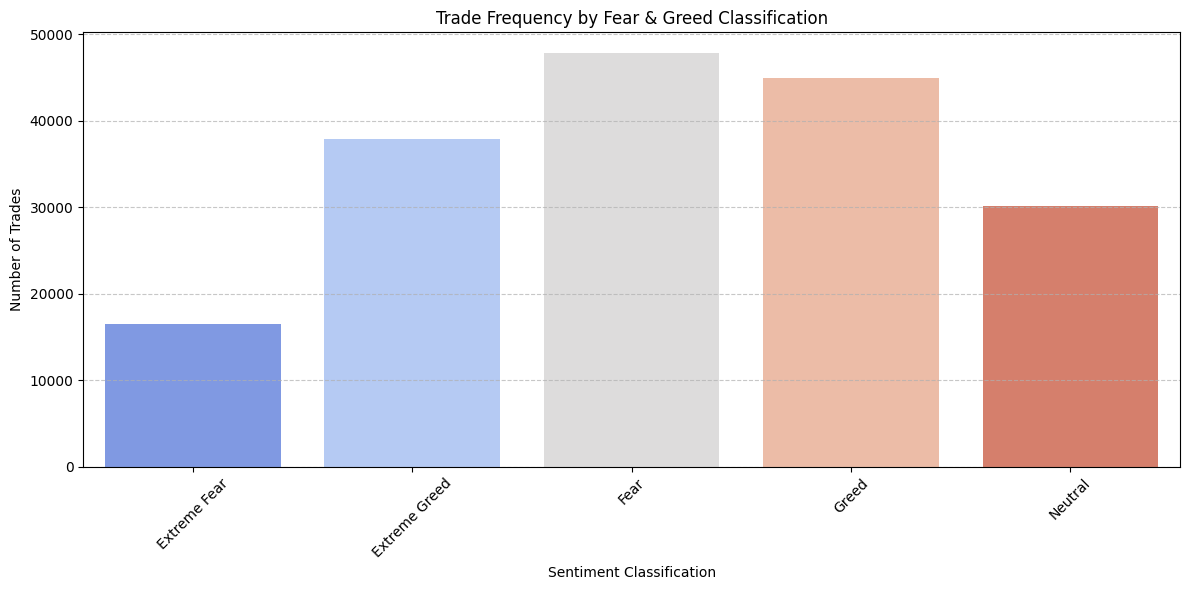

In [13]:
# Calculate trade frequency per sentiment
trade_frequency_by_sentiment = merged_data.groupby('classification').size().reset_index(name='Trade Count')
print("Trade Frequency by Sentiment Classification:")
display(trade_frequency_by_sentiment.round(2))
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='Trade Count', data=trade_frequency_by_sentiment, palette='coolwarm', hue='classification', legend=False)
plt.title('Trade Frequency by Fear & Greed Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 4.3 Trader Segmentation

Aggregated Trader Performance:


,Account,total_trades,total_pnl,winning_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,1373,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,3223,44.271978
2,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,5838,43.858463
3,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,1684,51.991355
4,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,-3.120360e+04,371,45.521472



Number of Frequent Traders (more than 3818.0 trades): 13
Number of Infrequent Traders (up to 3818.0 trades): 14

Number of Consistent Winners (Win Rate > 50% and Positive PnL): 3
Number of Inconsistent Traders: 24


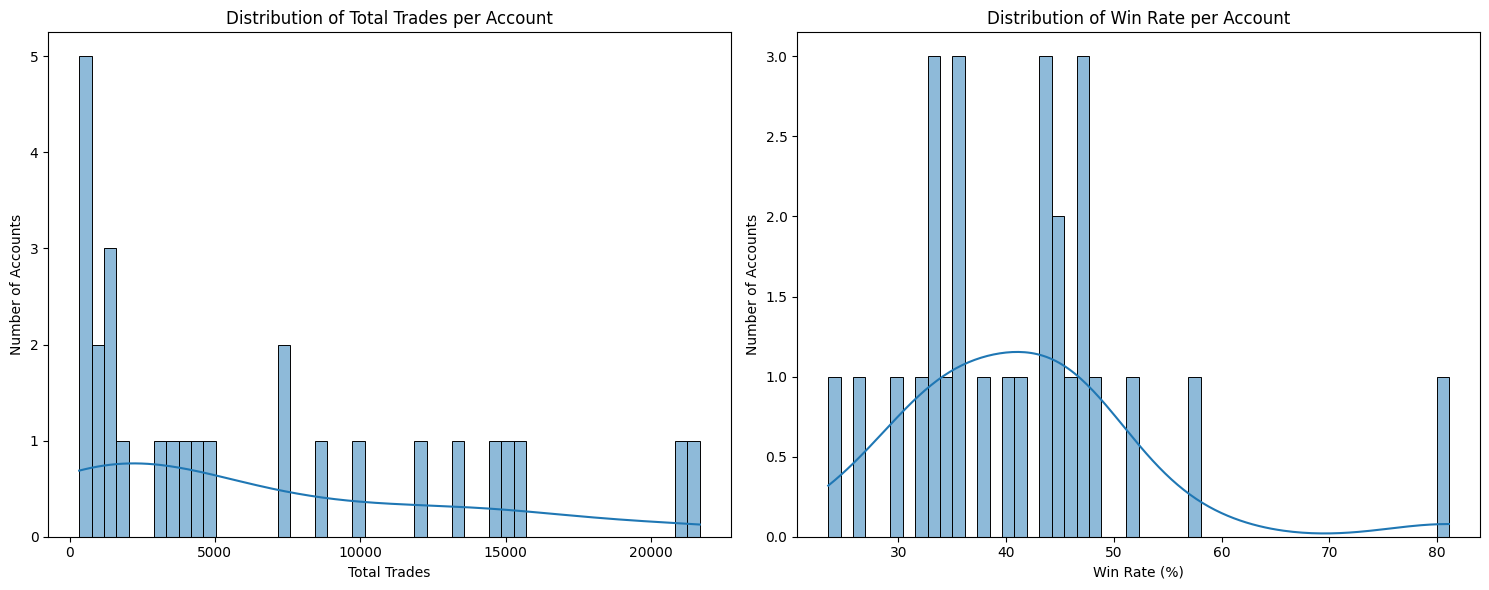

In [14]:
# Calculate aggregated metrics per account for segmentation
trader_performance = merged_data.groupby('Account').agg(
    total_trades=('Order ID', 'size'),
    total_pnl=('Closed PnL', 'sum'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

trader_performance['win_rate'] = (trader_performance['winning_trades'] / trader_performance['total_trades']) * 100

# Display summary of trader performance
print("Aggregated Trader Performance:")
display(trader_performance.head())

# Frequent vs. Infrequent Traders (based on total_trades)
# Using median as a simple split point
median_trades = trader_performance['total_trades'].median()
frequent_traders = trader_performance[trader_performance['total_trades'] > median_trades]
infrequent_traders = trader_performance[trader_performance['total_trades'] <= median_trades]

print(f"\nNumber of Frequent Traders (more than {median_trades} trades): {len(frequent_traders)}")
print(f"Number of Infrequent Traders (up to {median_trades} trades): {len(infrequent_traders)}")

#  Consistent Winners vs. Inconsistent Traders (based on win_rate and total_pnl)
# Define a threshold for 'consistent winners' (e.g., win rate > 50% and positive PnL)
consistent_winners = trader_performance[(trader_performance['win_rate'] > 50) & (trader_performance['total_pnl'] > 0)]
inconsistent_traders = trader_performance[~((trader_performance['win_rate'] > 50) & (trader_performance['total_pnl'] > 0))]

print(f"\nNumber of Consistent Winners (Win Rate > 50% and Positive PnL): {len(consistent_winners)}")
print(f"Number of Inconsistent Traders: {len(inconsistent_traders)}")

# plot the distribution of total_trades and win_rate
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(trader_performance['total_trades'], bins=50, kde=True)
plt.title('Distribution of Total Trades per Account')
plt.xlabel('Total Trades')
plt.ylabel('Number of Accounts')

plt.subplot(1, 2, 2)
sns.histplot(trader_performance['win_rate'], bins=50, kde=True)
plt.title('Distribution of Win Rate per Account')
plt.xlabel('Win Rate (%)')
plt.ylabel('Number of Accounts')

plt.tight_layout()
plt.show()

Drawdown Analysis

Maximum Drawdown per Account (Drawdown Proxy):


,Account,Max Drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,-327505.900056
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,-22505.512854
2,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,-20765.484966
3,0x2c229d22b100a7beb69122eed721cee9b24011dd,-3323.090682
4,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-72378.920559


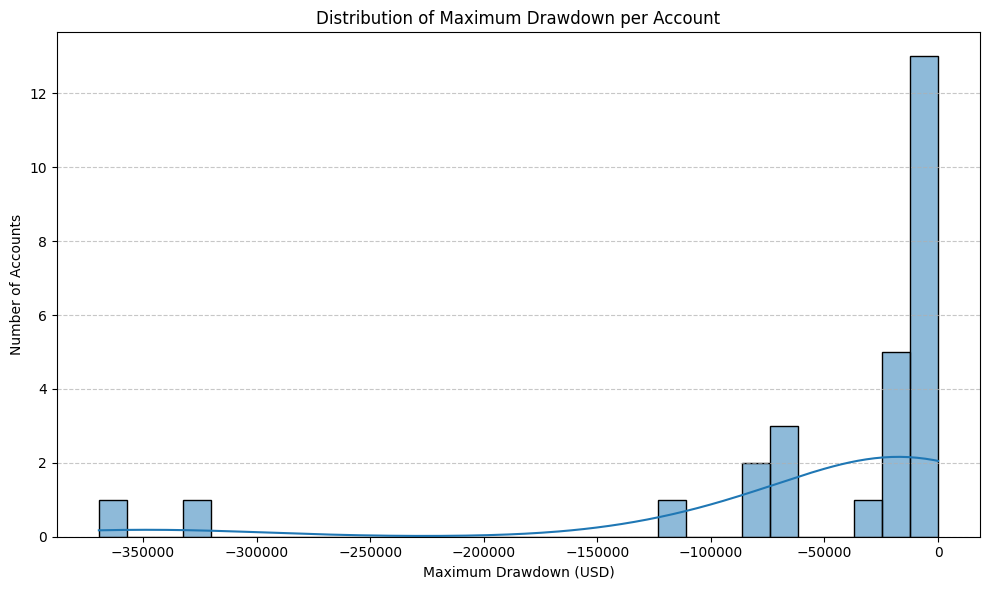

In [15]:
# Convert 'Date' column to datetime objects for time-series calculations
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

# Calculate daily PnL per account
daily_pnl = merged_data.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

# Sort by account and date to ensure correct cumulative sum calculation
daily_pnl = daily_pnl.sort_values(by=['Account', 'Date'])

# Calculate cumulative PnL for each account
daily_pnl['Cumulative PnL'] = daily_pnl.groupby('Account')['Closed PnL'].cumsum()

# Calculate the running maximum of cumulative PnL for each account
daily_pnl['Peak Cumulative PnL'] = daily_pnl.groupby('Account')['Cumulative PnL'].cummax()

# Calculate Drawdown: current cumulative PnL minus the peak cumulative PnL
daily_pnl['Drawdown'] = daily_pnl['Cumulative PnL'] - daily_pnl['Peak Cumulative PnL']

# The maximum drawdown for each account is the minimum (most negative) drawdown value
max_drawdown_per_account = daily_pnl.groupby('Account')['Drawdown'].min().reset_index()
max_drawdown_per_account.rename(columns={'Drawdown': 'Max Drawdown'}, inplace=True)

print("Maximum Drawdown per Account (Drawdown Proxy):")
display(max_drawdown_per_account.head())

# Optional: Plot distribution of Max Drawdown
plt.figure(figsize=(10, 6))
sns.histplot(max_drawdown_per_account['Max Drawdown'], bins=30, kde=True)
plt.title('Distribution of Maximum Drawdown per Account')
plt.xlabel('Maximum Drawdown (USD)')
plt.ylabel('Number of Accounts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Strategies

Based on my analysis of performance and trader behavior across different sentiment classifications, as well as the trader segmentation, here are two strategy ideas:

1.Capitalize on 'Fear' for Overall PnL: During days classified as 'Fear' sentiment, the market historically shows the highest overall total PnL (approximately $3.36M). Traders on these days tend to have a high trade frequency and a higher average trade size in USD, with a leaning towards a 'SELL' bias (Long/Short Ratio < 1). Therefore, a strategy could be: "During 'Fear' sentiment, consider a contrarian 'SELL' bias, potentially with larger position sizes, as these periods have historically yielded the highest overall positive PnL."

2.Seek Higher Win Rates during 'Extreme Greed': When the sentiment is 'Extreme Greed', the market exhibits the highest win rate (46.49%). Similar to 'Fear' days, traders during 'Extreme Greed' also show a 'SELL' bias. For traders, particularly those who might be inconsistent and looking to improve their win rate, this suggests: "On 'Extreme Greed' sentiment days, prioritize strategies with a 'SELL' bias to capitalize on the historically higher probability of winning trades."

5. Simple Predictive Model

To build a predictive model for next-day trader profitability,first need to prepare a dataset that includes daily sentiment features and aggregated trader behavior metrics,then define a target variable (e.g., whether a trader was profitable the next day) and create lagged features to enable prediction.

5.1 Feature Engineering and Target Definition

First,aggregate daily metrics for each account from `merged_data`. These will serve as our behavioral features.

In [16]:
# Aggregate daily behavioral metrics per account
daily_account_metrics = merged_data.groupby(['Date', 'Account']).agg(
    total_daily_pnl=('Closed PnL', 'sum'),
    daily_trades=('Order ID', 'size'),
    avg_daily_trade_size_tokens=('Size Tokens', 'mean'),
    avg_daily_trade_size_usd=('Size USD', 'mean'),
    num_daily_long_trades=('Side', lambda x: (x == 'BUY').sum()),
    num_daily_short_trades=('Side', lambda x: (x == 'SELL').sum())
).reset_index()

# Calculate daily Long/Short Ratio
daily_account_metrics['daily_long_short_ratio'] = daily_account_metrics['num_daily_long_trades'] / daily_account_metrics['num_daily_short_trades']
daily_account_metrics['daily_long_short_ratio'] = daily_account_metrics['daily_long_short_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

print("Daily Account Behavioral Metrics (first 5 rows):")
display(daily_account_metrics.head())

Daily Account Behavioral Metrics (first 5 rows):


,Date,Account,total_daily_pnl,daily_trades,avg_daily_trade_size_tokens,avg_daily_trade_size_usd,num_daily_long_trades,num_daily_short_trades,daily_long_short_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.083767,159.000000,3,0,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,1.312112,5556.203333,7,2,3.500000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,372.026274,10291.213636,5,6,0.833333
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,1779.000000,5304.975000,2,0,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,13299.000000,5116.256667,3,0,0.000000


Next, merge these daily account metrics with the sentiment data (`fear_greed_index`) based on the `Date`.

In [17]:
# Merge daily account metrics with sentiment data
# We only need 'Date', 'value', 'classification' from fear_greed_index
sentiment_features = fear_greed_index[['Date', 'value', 'classification']].copy()
sentiment_features.rename(columns={'value': 'sentiment_value', 'classification': 'sentiment_class'}, inplace=True)
sentiment_features['Date'] = pd.to_datetime(sentiment_features['Date'])

modeling_data = pd.merge(daily_account_metrics, sentiment_features, on='Date', how='left')

print("Combined Modeling Data (first 5 rows with sentiment):")
display(modeling_data.head())

Combined Modeling Data (first 5 rows with sentiment):


,Date,Account,total_daily_pnl,daily_trades,avg_daily_trade_size_tokens,avg_daily_trade_size_usd,num_daily_long_trades,num_daily_short_trades,daily_long_short_ratio,sentiment_value,sentiment_class
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.083767,159.000000,3,0,0.000000,63,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,1.312112,5556.203333,7,2,3.500000,75,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,372.026274,10291.213636,5,6,0.833333,72,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,1779.000000,5304.975000,2,0,0.000000,70,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,13299.000000,5116.256667,3,0,0.000000,67,Greed


Now,i will define our target variable: `next_day_profitable`. This will be `1` if the trader had a positive `total_daily_pnl` on the *next day*, and `0` otherwise, also need to create lagged versions of our features to predict the next day's profitability.

In [18]:
# Sort data to ensure correct lagging
modeling_data = modeling_data.sort_values(by=['Account', 'Date'])

# Create the target variable: next_day_profitable
# A trader is 'profitable' if their total_daily_pnl is > 0 the next day
modeling_data['next_day_profitable'] = modeling_data.groupby('Account')['total_daily_pnl'].shift(-1).apply(lambda x: 1 if x > 0 else 0)

# Drop the last day for each account as it won't have a 'next_day_profitable' target
# and fill any remaining NaNs in next_day_profitable with 0 (for non-profitable days)
modeling_data.dropna(subset=['next_day_profitable'], inplace=True)
modeling_data['next_day_profitable'] = modeling_data['next_day_profitable'].astype(int)

# Create lagged features (previous day's features to predict next day's profitability)
lag_features = ['total_daily_pnl', 'daily_trades', 'avg_daily_trade_size_tokens',
                'avg_daily_trade_size_usd', 'num_daily_long_trades', 'num_daily_short_trades',
                'daily_long_short_ratio', 'sentiment_value']

for feature in lag_features:
    modeling_data[f'prev_day_{feature}'] = modeling_data.groupby('Account')[feature].shift(1)

# For sentiment class, we need to handle it differently (one-hot encode the previous day's sentiment)
# First, convert 'sentiment_class' to categorical codes
modeling_data['sentiment_class_encoded'] = modeling_data['sentiment_class'].astype('category').cat.codes
modeling_data['prev_day_sentiment_class_encoded'] = modeling_data.groupby('Account')['sentiment_class_encoded'].shift(1)

# Drop rows with NaN values introduced by shifting (these are the first day for each account)
modeling_data.dropna(subset=[f'prev_day_{f}' for f in lag_features] + ['prev_day_sentiment_class_encoded'], inplace=True)

print("Modeling Data with Target and Lagged Features (first 5 rows):")
display(modeling_data.head())

Modeling Data with Target and Lagged Features (first 5 rows):


,Date,Account,total_daily_pnl,daily_trades,avg_daily_trade_size_tokens,avg_daily_trade_size_usd,num_daily_long_trades,num_daily_short_trades,daily_long_short_ratio,sentiment_value,sentiment_class,next_day_profitable,prev_day_total_daily_pnl,prev_day_daily_trades,prev_day_avg_daily_trade_size_tokens,prev_day_avg_daily_trade_size_usd,prev_day_num_daily_long_trades,prev_day_num_daily_short_trades,prev_day_daily_long_short_ratio,prev_day_sentiment_value,sentiment_class_encoded,prev_day_sentiment_class_encoded
533,2024-11-17,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,68,16.176471,7976.664412,0,68,0.0,90,Extreme Greed,0,0.0,177.0,1.587571,5089.718249,0.0,177.0,0.0,76.0,1,1.0
537,2024-11-18,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,40,7.500000,23734.500000,0,40,0.0,83,Extreme Greed,0,0.0,68.0,16.176471,7976.664412,0.0,68.0,0.0,90.0,1,1.0
559,2024-11-22,0x083384f897ee0f19899168e3b1bec365f52a9012,-21227.0,12,8.333333,28186.666667,12,0,0.0,94,Extreme Greed,1,0.0,40.0,7.500000,23734.500000,0.0,40.0,0.0,83.0,1,1.0
574,2024-11-26,0x083384f897ee0f19899168e3b1bec365f52a9012,1603.1,27,74.074074,17248.148148,12,15,0.8,79,Extreme Greed,0,-21227.0,12.0,8.333333,28186.666667,12.0,0.0,0.0,94.0,1,1.0
580,2024-11-28,0x083384f897ee0f19899168e3b1bec365f52a9012,-132271.0,82,15.853659,16058.536341,82,0,0.0,77,Extreme Greed,0,1603.1,27.0,74.074074,17248.148148,12.0,15.0,0.8,79.0,1,1.0


In [19]:
# One-hot encode the 'prev_day_sentiment_class_encoded' feature
# Revert to original sentiment_class for proper one-hot encoding labels
modeling_data['prev_day_sentiment_class'] = modeling_data['sentiment_class'].astype('category').cat.categories[modeling_data['prev_day_sentiment_class_encoded'].astype(int)]

modeling_data = pd.get_dummies(modeling_data, columns=['prev_day_sentiment_class'], prefix='sentiment')

print("Modeling Data after One-Hot Encoding (first 5 rows):")
display(modeling_data.head())

Modeling Data after One-Hot Encoding (first 5 rows):


,Date,Account,total_daily_pnl,daily_trades,avg_daily_trade_size_tokens,avg_daily_trade_size_usd,num_daily_long_trades,num_daily_short_trades,daily_long_short_ratio,sentiment_value,sentiment_class,next_day_profitable,prev_day_total_daily_pnl,prev_day_daily_trades,prev_day_avg_daily_trade_size_tokens,prev_day_avg_daily_trade_size_usd,prev_day_num_daily_long_trades,prev_day_num_daily_short_trades,prev_day_daily_long_short_ratio,prev_day_sentiment_value,sentiment_class_encoded,prev_day_sentiment_class_encoded,sentiment_Extreme Fear,sentiment_Extreme Greed,sentiment_Fear,sentiment_Greed,sentiment_Neutral
533,2024-11-17,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,68,16.176471,7976.664412,0,68,0.0,90,Extreme Greed,0,0.0,177.0,1.587571,5089.718249,0.0,177.0,0.0,76.0,1,1.0,False,True,False,False,False
537,2024-11-18,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,40,7.500000,23734.500000,0,40,0.0,83,Extreme Greed,0,0.0,68.0,16.176471,7976.664412,0.0,68.0,0.0,90.0,1,1.0,False,True,False,False,False
559,2024-11-22,0x083384f897ee0f19899168e3b1bec365f52a9012,-21227.0,12,8.333333,28186.666667,12,0,0.0,94,Extreme Greed,1,0.0,40.0,7.500000,23734.500000,0.0,40.0,0.0,83.0,1,1.0,False,True,False,False,False
574,2024-11-26,0x083384f897ee0f19899168e3b1bec365f52a9012,1603.1,27,74.074074,17248.148148,12,15,0.8,79,Extreme Greed,0,-21227.0,12.0,8.333333,28186.666667,12.0,0.0,0.0,94.0,1,1.0,False,True,False,False,False
580,2024-11-28,0x083384f897ee0f19899168e3b1bec365f52a9012,-132271.0,82,15.853659,16058.536341,82,0,0.0,77,Extreme Greed,0,1603.1,27.0,74.074074,17248.148148,12.0,15.0,0.8,79.0,1,1.0,False,True,False,False,False


5.2 Model Training and Evaluation


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# Exclude the original string sentiment_class column and the intermediate encoded integer columns
X_cols = [col for col in modeling_data.columns if col.startswith('prev_day_') or (col.startswith('sentiment_') and col not in ['sentiment_class', 'sentiment_class_encoded', 'prev_day_sentiment_class_encoded'])]
X = modeling_data[X_cols]
y = modeling_data['next_day_profitable']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight for imbalanced target
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Training set shape: (1669, 15)
Testing set shape: (418, 15)

Model Evaluation:
Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.54      0.33      0.41       153
           1       0.68      0.84      0.75       265

    accuracy                           0.65       418
   macro avg       0.61      0.58      0.58       418
weighted avg       0.63      0.65      0.63       418



## 6. Clustering Traders into Behavioral Archetypes

To identify distinct behavioral archetypes among traders, we'll use clustering techniques on their performance metrics. This will help us segment traders into groups with similar characteristics.

### 6.1 Data Preparation for Clustering

We will use the `trader_performance` data we calculated earlier. Before applying clustering, it's essential to scale the features to ensure that no single feature dominates the clustering process due to its magnitude.

In [21]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
clustering_features = trader_performance[['total_trades', 'total_pnl', 'win_rate']]

# Handle potential NaN or infinite values that might arise from earlier calculations, although we already handled some during merging.
clustering_features = clustering_features.fillna(0)
clustering_features = clustering_features.replace([np.inf, -np.inf], 0)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

print("Scaled features (first 5 rows):")
display(pd.DataFrame(scaled_features, columns=clustering_features.columns).head())

Scaled features (first 5 rows):


,total_trades,total_pnl,win_rate
0,-0.422171,2.476434,-0.499751
1,0.109805,-0.538440,0.256345
2,1.036538,-0.374175,0.218725
3,-0.511141,-0.303882,0.958640
4,-0.883617,-0.692042,0.370022


### 6.2 K-Means Clustering and Optimal K Determination

We will use the K-Means algorithm. To determine an appropriate number of clusters (K), we'll use the Elbow method, which plots the within-cluster sum of squares (WCSS) against the number of clusters.

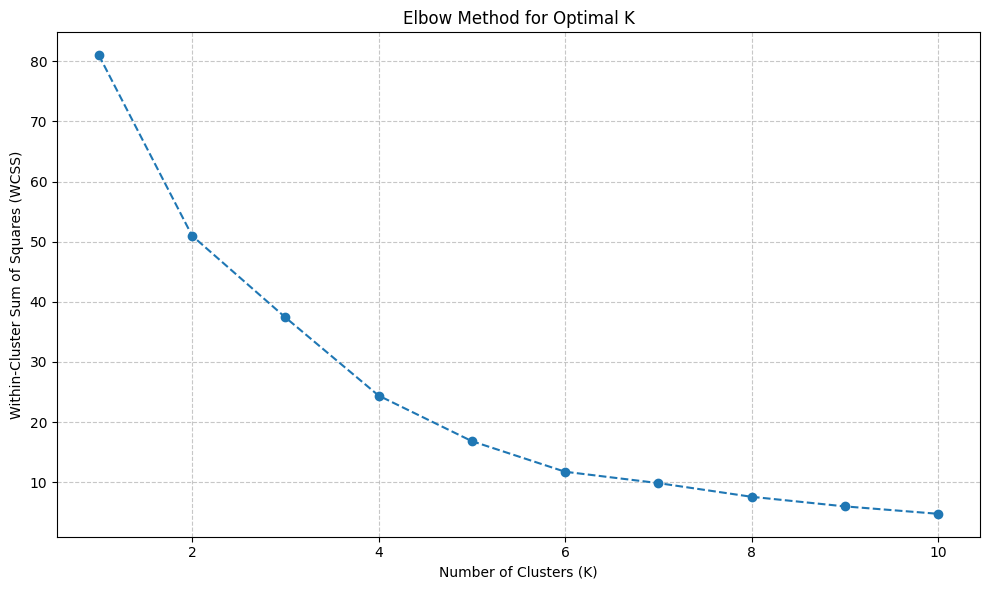

In [22]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Cluster Summary (K=3):


,cluster,total_trades,total_pnl,win_rate
0,0,2766.67,102703.50,40.54
1,1,9275.50,1871806.21,34.84
2,2,15559.29,455159.57,45.70


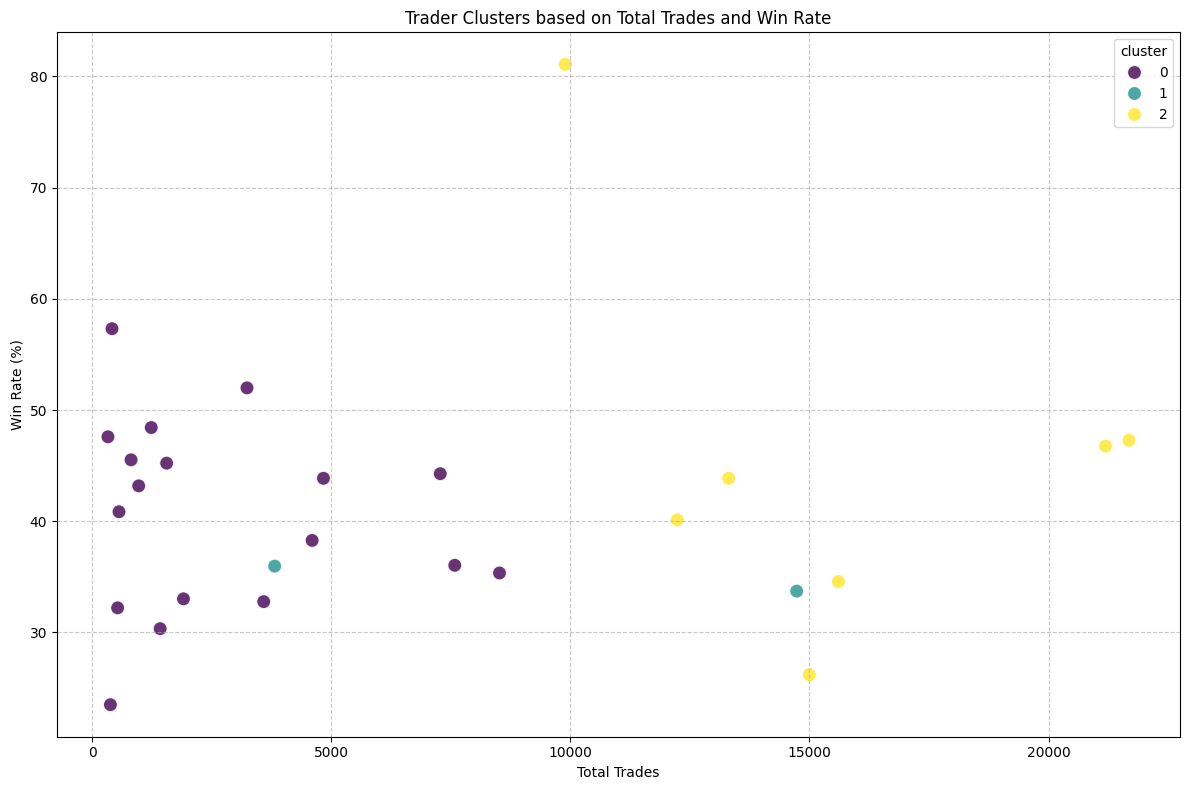

In [23]:
# Apply K-Means with the chosen number of clusters (e.g., K=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
trader_performance['cluster'] = kmeans.fit_predict(scaled_features)

# Analyze the characteristics of each cluster
cluster_summary = trader_performance.groupby('cluster')[['total_trades', 'total_pnl', 'win_rate']].mean().reset_index()

print(f"\nCluster Summary (K={optimal_k}):")
display(cluster_summary.round(2))

# Visualize the clusters (e.g., using a scatter plot of two key features)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='total_trades', y='win_rate', hue='cluster', data=trader_performance, palette='viridis', s=100, alpha=0.8)
plt.title('Trader Clusters based on Total Trades and Win Rate')
plt.xlabel('Total Trades')
plt.ylabel('Win Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Starting Predictive Model Logic ---

--- Model Evaluation Report ---
Accuracy: 0.66
              precision    recall  f1-score   support

           0       0.56      0.40      0.47       174
           1       0.69      0.81      0.75       288

    accuracy                           0.66       462
   macro avg       0.63      0.61      0.61       462
weighted avg       0.64      0.66      0.64       462


--- Confusion Matrix ---


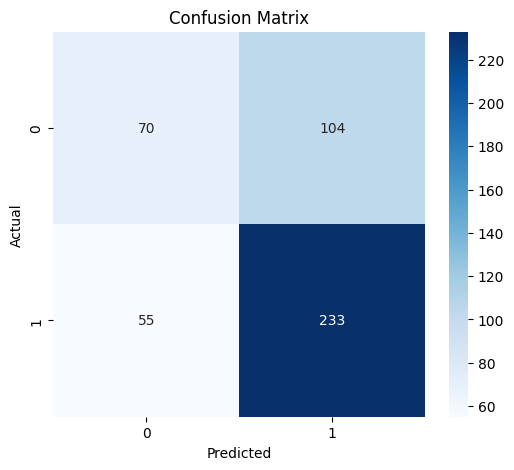


--- Feature Importances ---


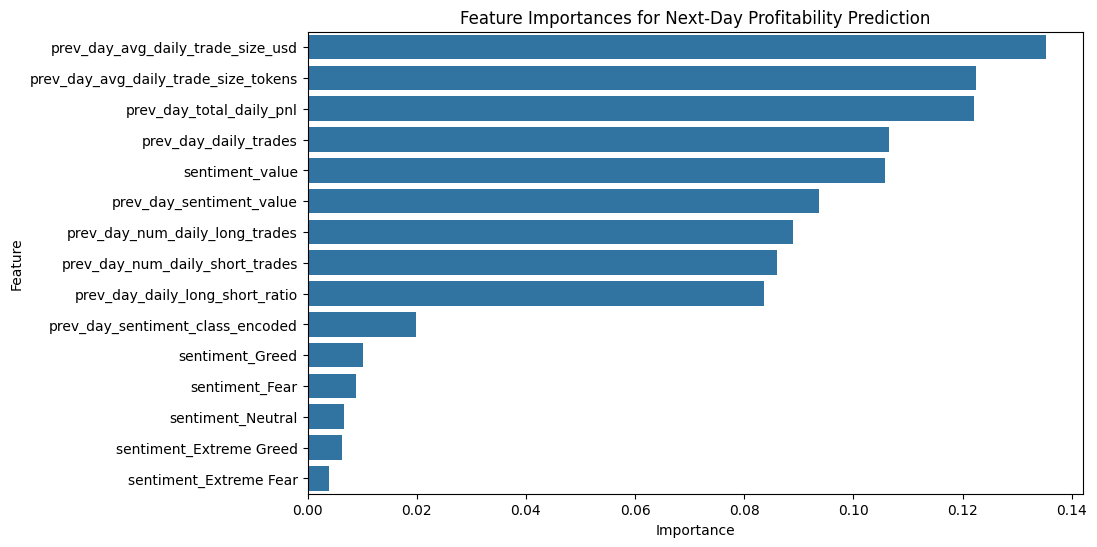

--- Predictive Model Logic End ---


In [50]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading and Preprocessing ---
def load_data():
    fear_greed_index = pd.read_csv('/content/fear_greed_index.csv')
    historical_data = pd.read_csv('/content/historical_data.csv', low_memory=False) # Handle mixed types

    # Data Cleaning and Merging
    fear_greed_index['date'] = pd.to_datetime(fear_greed_index['date'])
    historical_data['Timestamp IST'] = pd.to_datetime(historical_data['Timestamp IST'], dayfirst=True, errors='coerce')

    # Drop rows with NaT from date conversion (if any)
    historical_data.dropna(subset=['Timestamp IST'], inplace=True)

    # Ensure 'Date' columns are datetime64[ns] for consistent merging
    historical_data['Date'] = historical_data['Timestamp IST'].dt.normalize()
    fear_greed_index['Date'] = fear_greed_index['date'].dt.normalize()

    merged_data = pd.merge(historical_data, fear_greed_index, on='Date', how='inner')

    # Drop duplicates after merging as well
    merged_data = merged_data.drop_duplicates()

    return fear_greed_index, historical_data, merged_data

fear_greed_index, historical_data, merged_data = load_data()

print("--- Starting Predictive Model Logic ---")

# --- Re-create modeling_data for prediction ---
daily_account_metrics = merged_data.groupby(['Date', 'Account']).agg(
    total_daily_pnl=('Closed PnL', 'sum'),
    daily_trades=('Order ID', 'size'),
    avg_daily_trade_size_tokens=('Size Tokens', 'mean'),
    avg_daily_trade_size_usd=('Size USD', 'mean'),
    num_daily_long_trades=('Side', lambda x: (x == 'BUY').sum()),
    num_daily_short_trades=('Side', lambda x: (x == 'SELL').sum())
).reset_index()

daily_account_metrics['daily_long_short_ratio'] = daily_account_metrics['num_daily_long_trades'] / daily_account_metrics['num_daily_short_trades']
daily_account_metrics['daily_long_short_ratio'] = daily_account_metrics['daily_long_short_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

sentiment_features = fear_greed_index[['Date', 'value', 'classification']].copy()
sentiment_features.rename(columns={'value': 'sentiment_value', 'classification': 'sentiment_class'}, inplace=True)
sentiment_features['Date'] = pd.to_datetime(sentiment_features['Date']) # This conversion is now redundant but harmless as fear_greed_index['Date'] is already datetime64[ns]
modeling_data = pd.merge(daily_account_metrics, sentiment_features, on='Date', how='left')

modeling_data = modeling_data.sort_values(by=['Account', 'Date'])
modeling_data['next_day_profitable'] = modeling_data.groupby('Account')['total_daily_pnl'].shift(-1).apply(lambda x: 1 if x > 0 else 0)
modeling_data.dropna(subset=['next_day_profitable'], inplace=True)
modeling_data['next_day_profitable'] = modeling_data['next_day_profitable'].astype(int)

lag_features = ['total_daily_pnl', 'daily_trades', 'avg_daily_trade_size_tokens',
                'avg_daily_trade_size_usd', 'num_daily_long_trades', 'num_daily_short_trades',
                'daily_long_short_ratio', 'sentiment_value']
for feature in lag_features:
    modeling_data[f'prev_day_{feature}'] = modeling_data.groupby('Account')[feature].shift(1)

modeling_data['sentiment_class_encoded'] = modeling_data['sentiment_class'].astype('category').cat.codes
modeling_data['prev_day_sentiment_class_encoded'] = modeling_data.groupby('Account')['sentiment_class_encoded'].shift(1)
modeling_data.dropna(subset=[f'prev_day_{f}' for f in lag_features] + ['prev_day_sentiment_class_encoded'], inplace=True)

# Ensure previous day sentiment class uses consistent categories for encoding
original_sentiment_categories = modeling_data['sentiment_class'].astype('category').cat.categories
modeling_data['prev_day_sentiment_class'] = pd.Categorical.from_codes(modeling_data['prev_day_sentiment_class_encoded'].astype(int),
                                                                   categories=original_sentiment_categories)

modeling_data = pd.get_dummies(modeling_data, columns=['prev_day_sentiment_class'], prefix='sentiment')

X_cols = [col for col in modeling_data.columns if col.startswith('prev_day_') or (col.startswith('sentiment_') and col not in ['sentiment_class', 'sentiment_class_encoded', 'prev_day_sentiment_class_encoded'])]
X = modeling_data[X_cols]
y = modeling_data['next_day_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight for imbalanced target
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Model Evaluation Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix')
plt.show()

print("\n--- Feature Importances ---")
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, ax=ax_fi)
ax_fi.set_title('Feature Importances for Next-Day Profitability Prediction')
ax_fi.set_xlabel('Importance')
ax_fi.set_ylabel('Feature')
plt.show()

print("--- Predictive Model Logic End ---")

In [56]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Install necessary libraries (will only run once if not already installed)
import subprocess
import sys
st.set_page_config(layout="wide", page_title="Trader Performance Analysis")
st.title("Trader Performance and Behavior Analysis")
@st.cache_data
def install_packages():
    packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'streamlit']
    for package in packages:
        try:
            __import__(package)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_packages()

# Set Streamlit page config
st.set_page_config(layout="wide", page_title="Crypto Trader Analysis Dashboard")

# --- 1. Data Loading and Preprocessing ---
@st.cache_data
def load_data():
    fear_greed_index = pd.read_csv('fear_greed_index.csv')
    historical_data = pd.read_csv('historical_data.csv', low_memory=False)

    fear_greed_index['date'] = pd.to_datetime(fear_greed_index['date'])
    historical_data['Timestamp IST'] = pd.to_datetime(historical_data['Timestamp IST'], dayfirst=True, errors='coerce')
    historical_data.dropna(subset=['Timestamp IST'], inplace=True)

    historical_data['Date'] = historical_data['Timestamp IST'].dt.normalize()
    fear_greed_index['Date'] = fear_greed_index['date'].dt.normalize()

    merged_data = pd.merge(historical_data, fear_greed_index, on='Date', how='inner')
    merged_data = merged_data.drop_duplicates()

    return fear_greed_index, historical_data, merged_data

fear_greed_index, historical_data, merged_data = load_data()

# --- Helper function for Predictive Model ---
@st.cache_data
def prepare_and_train_model(merged_data, fear_greed_index):
    daily_account_metrics = merged_data.groupby(['Date', 'Account']).agg(
        total_daily_pnl=('Closed PnL', 'sum'),
        daily_trades=('Order ID', 'size'),
        avg_daily_trade_size_tokens=('Size Tokens', 'mean'),
        avg_daily_trade_size_usd=('Size USD', 'mean'),
        num_daily_long_trades=('Side', lambda x: (x == 'BUY').sum()),
        num_daily_short_trades=('Side', lambda x: (x == 'SELL').sum())
    ).reset_index()

    daily_account_metrics['daily_long_short_ratio'] = daily_account_metrics['num_daily_long_trades'] / daily_account_metrics['num_daily_short_trades']
    daily_account_metrics['daily_long_short_ratio'] = daily_account_metrics['daily_long_short_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

    sentiment_features = fear_greed_index[['Date', 'value', 'classification']].copy()
    sentiment_features.rename(columns={'value': 'sentiment_value', 'classification': 'sentiment_class'}, inplace=True)
    sentiment_features['Date'] = pd.to_datetime(sentiment_features['Date'])
    modeling_data = pd.merge(daily_account_metrics, sentiment_features, on='Date', how='left')

    modeling_data = modeling_data.sort_values(by=['Account', 'Date'])
    modeling_data['next_day_profitable'] = modeling_data.groupby('Account')['total_daily_pnl'].shift(-1).apply(lambda x: 1 if x > 0 else 0)
    modeling_data.dropna(subset=['next_day_profitable'], inplace=True)
    modeling_data['next_day_profitable'] = modeling_data['next_day_profitable'].astype(int)

    lag_features = ['total_daily_pnl', 'daily_trades', 'avg_daily_trade_size_tokens',
                    'avg_daily_trade_size_usd', 'num_daily_long_trades', 'num_daily_short_trades',
                    'daily_long_short_ratio', 'sentiment_value']
    for feature in lag_features:
        modeling_data[f'prev_day_{feature}'] = modeling_data.groupby('Account')[feature].shift(1)

    modeling_data['sentiment_class_encoded'] = modeling_data['sentiment_class'].astype('category').cat.codes
    modeling_data['prev_day_sentiment_class_encoded'] = modeling_data.groupby('Account')['sentiment_class_encoded'].shift(1)
    modeling_data.dropna(subset=[f'prev_day_{f}' for f in lag_features] + ['prev_day_sentiment_class_encoded'], inplace=True)

    original_sentiment_categories = modeling_data['sentiment_class'].astype('category').cat.categories
    modeling_data['prev_day_sentiment_class'] = pd.Categorical.from_codes(modeling_data['prev_day_sentiment_class_encoded'].astype(int),
                                                                       categories=original_sentiment_categories)
    modeling_data = pd.get_dummies(modeling_data, columns=['prev_day_sentiment_class'], prefix='sentiment')

    X_cols = [col for col in modeling_data.columns if col.startswith('prev_day_') or (col.startswith('sentiment_') and col not in ['sentiment_class', 'sentiment_class_encoded', 'prev_day_sentiment_class_encoded'])]
    X = modeling_data[X_cols]
    y = modeling_data['next_day_profitable']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return model, X_test, y_test, y_pred, X_cols


# --- Sidebar Navigation ---
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", [
    "Overview",
    "Sentiment Analysis",
    "Trader Segmentation",
    "Drawdown Analysis",
    "Predictive Model"
])

# --- Page: Overview ---
if page == "Overview":
    st.title("Dashboard Overview")
    st.write("### Key Performance Metrics")

    col1, col2, col3 = st.columns(3)

    with col1:
        total_trades = len(merged_data)
        st.metric("Total Trades", f"{total_trades:,}")

    with col2:
        winning_trades = merged_data[merged_data['Closed PnL'] > 0]
        win_rate = (len(winning_trades) / total_trades) * 100 if total_trades > 0 else 0
        st.metric("Overall Win Rate", f"{win_rate:.2f}%")

    with col3:
        avg_trade_size_usd = merged_data['Size USD'].mean()
        st.metric("Average Trade Size (USD)", f"${avg_trade_size_usd:,.2f}")

    col4, col5 = st.columns(2)

    with col4:
        num_long = len(merged_data[merged_data['Side'] == 'BUY'])
        num_short = len(merged_data[merged_data['Side'] == 'SELL'])
        long_short_ratio = num_long / num_short if num_short > 0 else float('inf')
        st.metric("Long/Short Ratio", f"{long_short_ratio:.2f}")

    with col5:
        daily_pnl_per_account = merged_data.groupby(['Date', 'Account'])['Closed PnL'].sum().reset_index()
        total_pnl = daily_pnl_per_account['Closed PnL'].sum()
        st.metric("Total Closed PnL", f"${total_pnl:,.2f}")

    st.write("### Data Snapshots")
    st.subheader("Fear & Greed Index (Head)")
    st.dataframe(fear_greed_index.head())
    st.subheader("Historical Trading Data (Head)")
    st.dataframe(historical_data.head())
    st.subheader("Merged Data (Head)")
    st.dataframe(merged_data.head())

# --- Page: Sentiment Analysis ---
elif page == "Sentiment Analysis":
    st.title("Trader Behavior Analysis by Sentiment")

    st.write("#### Performance by Sentiment Classification")
    pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].sum().reset_index()
    winning_trades_by_sentiment = merged_data[merged_data['Closed PnL'] > 0].groupby('classification').size().reset_index(name='Winning Trades')
    total_trades_by_sentiment = merged_data.groupby('classification').size().reset_index(name='Total Trades')
    win_rate_by_sentiment = pd.merge(winning_trades_by_sentiment, total_trades_by_sentiment, on='classification', how='outer').fillna(0)
    win_rate_by_sentiment['Win Rate (%)'] = (win_rate_by_sentiment['Winning Trades'] / win_rate_by_sentiment['Total Trades']) * 100
    performance_by_sentiment = pd.merge(pnl_by_sentiment, win_rate_by_sentiment[['classification', 'Win Rate (%)']], on='classification', how='left')
    st.dataframe(performance_by_sentiment.round(2))

    col1, col2 = st.columns(2)
    with col1:
        fig_pnl, ax_pnl = plt.subplots(figsize=(10, 6))
        sns.barplot(x='classification', y='Closed PnL', data=performance_by_sentiment, palette='viridis', ax=ax_pnl, hue='classification', legend=False)
        ax_pnl.set_title('Total PnL by Fear & Greed Classification')
        ax_pnl.set_xlabel('Sentiment Classification')
        ax_pnl.set_ylabel('Total Closed PnL')
        ax_pnl.tick_params(axis='x', rotation=45)
        st.pyplot(fig_pnl)

    with col2:
        fig_winrate, ax_winrate = plt.subplots(figsize=(10, 6))
        sns.barplot(x='classification', y='Win Rate (%)', data=performance_by_sentiment, palette='magma', ax=ax_winrate, hue='classification', legend=False)
        ax_winrate.set_title('Win Rate by Fear & Greed Classification')
        ax_winrate.set_xlabel('Sentiment Classification')
        ax_winrate.set_ylabel('Win Rate (%)')
        ax_winrate.tick_params(axis='x', rotation=45)
        st.pyplot(fig_winrate)

    st.write("#### Trade Frequency by Sentiment Classification")
    trade_frequency_by_sentiment = merged_data.groupby('classification').size().reset_index(name='Trade Count')
    st.dataframe(trade_frequency_by_sentiment.round(2))
    fig_freq, ax_freq = plt.subplots(figsize=(10, 6))
    sns.barplot(x='classification', y='Trade Count', data=trade_frequency_by_sentiment, palette='coolwarm', ax=ax_freq, hue='classification', legend=False)
    ax_freq.set_title('Trade Frequency by Fear & Greed Classification')
    ax_freq.set_xlabel('Sentiment Classification')
    ax_freq.set_ylabel('Number of Trades')
    ax_freq.tick_params(axis='x', rotation=45)
    st.pyplot(fig_freq)

    st.write("#### Long/Short Bias by Sentiment Classification")
    long_short_by_sentiment = merged_data.groupby(['classification', 'Side']).size().unstack(fill_value=0).reset_index()
    long_short_by_sentiment['Long/Short Ratio'] = long_short_by_sentiment['BUY'] / long_short_by_sentiment['SELL']
    st.dataframe(long_short_by_sentiment.round(2))
    fig_ls, ax_ls = plt.subplots(figsize=(10, 6))
    sns.barplot(x='classification', y='Long/Short Ratio', data=long_short_by_sentiment, palette='coolwarm', ax=ax_ls, hue='classification', legend=False)
    ax_ls.set_title('Long/Short Ratio by Fear & Greed Classification')
    ax_ls.set_xlabel('Sentiment Classification')
    ax_ls.set_ylabel('Long/Short Ratio')
    ax_ls.tick_params(axis='x', rotation=45)
    st.pyplot(fig_ls)

    st.write("#### Average Position Sizes by Sentiment Classification")
    position_size_by_sentiment = merged_data.groupby('classification')[['Size Tokens', 'Size USD']].mean().reset_index()
    st.dataframe(position_size_by_sentiment.round(2))

# --- Page: Trader Segmentation ---
elif page == "Trader Segmentation":
    st.title("Trader Segmentation into Behavioral Archetypes")

    trader_performance = merged_data.groupby('Account').agg(
        total_trades=('Order ID', 'size'),
        total_pnl=('Closed PnL', 'sum'),
        winning_trades=('Closed PnL', lambda x: (x > 0).sum())
    ).reset_index()
    trader_performance['win_rate'] = (trader_performance['winning_trades'] / trader_performance['total_trades']) * 100
    st.write("### Aggregated Trader Performance")
    st.dataframe(trader_performance.head())

    st.write("### Clustering Traders (K-Means)")
    clustering_features = trader_performance[['total_trades', 'total_pnl', 'win_rate']]
    clustering_features = clustering_features.fillna(0).replace([np.inf, -np.inf], 0)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(clustering_features)

    # Using optimal K=3 from notebook analysis
    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    trader_performance['cluster'] = kmeans.fit_predict(scaled_features)

    cluster_summary = trader_performance.groupby('cluster')[['total_trades', 'total_pnl', 'win_rate']].mean().reset_index()
    st.write(f"#### Cluster Summary (K={optimal_k})")
    st.dataframe(cluster_summary.round(2))

    fig_cluster, ax_cluster = plt.subplots(figsize=(12, 8))
    sns.scatterplot(x='total_trades', y='win_rate', hue='cluster', data=trader_performance, palette='viridis', s=100, alpha=0.8, ax=ax_cluster)
    ax_cluster.set_title('Trader Clusters based on Total Trades and Win Rate')
    ax_cluster.set_xlabel('Total Trades')
    ax_cluster.set_ylabel('Win Rate (%)')
    ax_cluster.grid(True, linestyle='--', alpha=0.7)
    st.pyplot(fig_cluster)

    st.write("#### Trader Archetypes Identified")
    st.markdown("Based on K-Means clustering, traders are segmented into archetypes with distinct characteristics in terms of trade volume, profitability, and win rate.")

# --- Page: Drawdown Analysis ---
elif page == "Drawdown Analysis":
    st.title("Drawdown Analysis")

    st.write("### Maximum Drawdown per Account")
    merged_data['Date'] = pd.to_datetime(merged_data['Date'])
    daily_pnl = merged_data.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()
    daily_pnl = daily_pnl.sort_values(by=['Account', 'Date'])
    daily_pnl['Cumulative PnL'] = daily_pnl.groupby('Account')['Closed PnL'].cumsum()
    daily_pnl['Peak Cumulative PnL'] = daily_pnl.groupby('Account')['Cumulative PnL'].cummax()
    daily_pnl['Drawdown'] = daily_pnl['Cumulative PnL'] - daily_pnl['Peak Cumulative PnL']
    max_drawdown_per_account = daily_pnl.groupby('Account')['Drawdown'].min().reset_index()
    max_drawdown_per_account.rename(columns={'Drawdown': 'Max Drawdown'}, inplace=True)
    st.dataframe(max_drawdown_per_account.head())

    fig_drawdown, ax_drawdown = plt.subplots(figsize=(10, 6))
    sns.histplot(max_drawdown_per_account['Max Drawdown'], bins=30, kde=True, ax=ax_drawdown)
    ax_drawdown.set_title('Distribution of Maximum Drawdown per Account')
    ax_drawdown.set_xlabel('Maximum Drawdown (USD)')
    ax_drawdown.set_ylabel('Number of Accounts')
    ax_drawdown.grid(axis='y', linestyle='--', alpha=0.7)
    st.pyplot(fig_drawdown)

# --- Page: Predictive Model ---
elif page == "Predictive Model":
    st.title("Predictive Model for Next-Day Trader Profitability")

    st.write("This section trains a RandomForestClassifier to predict whether a trader will be profitable the next day based on their previous day's activity and market sentiment.")

    model, X_test, y_test, y_pred, X_cols = prepare_and_train_model(merged_data, fear_greed_index)

    st.write("### Model Evaluation Report")
    report = classification_report(y_test, y_pred, output_dict=True)
    st.json(report)

    st.write("### Confusion Matrix")
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm)
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_title('Confusion Matrix')
    st.pyplot(fig_cm)

    st.write("### Feature Importances")
    feature_importances = pd.Series(model.feature_importances_, index=X_cols).sort_values(ascending=False)
    fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, ax=ax_fi)
    ax_fi.set_title('Feature Importances for Next-Day Profitability Prediction')
    ax_fi.set_xlabel('Importance')
    ax_fi.set_ylabel('Feature')
    st.pyplot(fig_fi)

Overwriting app.py


In [57]:
from pyngrok import ngrok
NGROK_AUTH_TOKEN = "38neOyWD6labrDJ5UEN1sZansEb_3SnkmXgJhdswbrSqiGZdG"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
# Terminate open tunnels if any
ngrok.kill()

# Open a tunnel on port 8501 (default Streamlit port)
public_url = ngrok.connect(8501)
print(f"Streamlit App is live at: {public_url.public_url}")

# Run the app
!streamlit run app.py >/dev/null

Streamlit App is live at: https://nonreverentially-unwhipt-marlee.ngrok-free.dev
